In [58]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from simplipy import SimpliPyEngine

from tqdm import tqdm

from flash_ansr import get_path
from flash_ansr.eval.metrics import bootstrapped_metric_ci, naninfmean
from flash_ansr.eval import (
    arrow_notation,
    DEFAULT_NEGATIVES,
    fill_none_with_defaults,
    compute_derived_metrics,
    apply_variable_renaming,
)

In [59]:
# All results (1M rebuttal baselines + A-track 10M/100M) live here
PATH_TO_EVALUATION_DATA = get_path('results', 'evaluation', 'scaling')
os.path.exists(PATH_TO_EVALUATION_DATA)

True

In [60]:
engine = SimpliPyEngine.load('dev_7-3', install=True)

In [61]:
# Track Z: inference-strategy ablation on the same 120M baseline checkpoint.
# Three configurations:
#   * v23.0-120M           -- softmax sampling (current default; LM refiner)
#   * v23.0-120M-Z1-bfgs   -- softmax sampling + BFGS refiner (vs. LM)
#   * v23.0-120M-Z2-beam   -- beam search (vs. softmax sampling)
#
# The pickle filename prefixes differ from each other --- the loader cell
# below filters by `scaling_parameter` as a literal prefix string, so we
# encode the prefix here (not the actual generation-config key name).
results = {
    'v23.0-120M':           {'scaling_parameter': 'choices'},        # softmax baseline
    'v23.0-120M-Z1-bfgs':   {'scaling_parameter': 'bfgs_choices'},   # BFGS refiner variant
    'v23.0-120M-Z2-beam':   {'scaling_parameter': 'beam_search'},    # beam decoder variant
}


In [62]:
TEST_SETS = ['val', 'fastsrb'][1:]
TEST_SETS

['fastsrb']

In [63]:
models_not_found = []
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    results[model]['evaluations_list'] = {}
    found_dataset = False
    for dataset in TEST_SETS:
        try:
            evaluations_list = os.listdir(os.path.join(PATH_TO_EVALUATION_DATA, model, dataset))
            found_dataset = True
        except FileNotFoundError:
            print(f"{os.path.join(PATH_TO_EVALUATION_DATA, model, dataset)} not found, skipping.")
            continue

        evaluations_list = [d for d in evaluations_list if d.startswith(f'{scaling_parameter}_')]
        scaling_values = [int(d.split('_')[-1].split('.')[0]) for d in evaluations_list]

        scaling_values_argsort = np.argsort(scaling_values)
        scaling_values = [scaling_values[i] for i in scaling_values_argsort]
        evaluations_list = [evaluations_list[i] for i in scaling_values_argsort]

        results[model]['scaling_values'] = scaling_values
        results[model]['evaluations_list'][dataset] = evaluations_list
        results[model]['results'] = {}

        print(f"{model}: Found {len(evaluations_list)} evaluations with scaling values: {scaling_values}")
        for d in evaluations_list:
            print(f" - {d}")

    if not found_dataset:
        print(f"No datasets found for model {model}, removing from results.")
        models_not_found.append(model)

for model_not_found in models_not_found:
    del results[model_not_found]

v23.0-20M-A-S1: Found 7 evaluations with scaling values: [1, 4, 16, 64, 256, 1024, 4096]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
 - choices_04096.pkl
v23.0-20M-A-S10: Found 8 evaluations with scaling values: [1, 4, 16, 32, 64, 256, 2048, 8192]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00032.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_02048.pkl
 - choices_08192.pkl
v23.0-20M-A-S100: Found 8 evaluations with scaling values: [1, 4, 16, 32, 64, 256, 2048, 8192]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00032.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_02048.pkl
 - choices_08192.pkl
v23.0-20M-A-U1: Found 7 evaluations with scaling values: [1, 4, 16, 64, 256, 1024, 4096]
 - choices_00001.pkl
 - choices_00004.pkl
 - choices_00016.pkl
 - choices_00064.pkl
 - choices_00256.pkl
 - choices_01024.pkl
 - choices_04096.pkl
v23

In [64]:
# Load the evaluation results
for model in results.keys():
    scaling_parameter = results[model]['scaling_parameter']
    for dataset in TEST_SETS:
        if dataset not in results[model]['evaluations_list']:
            continue
        for d in tqdm(results[model]['evaluations_list'][dataset], desc="Loading evaluation results"):
            for test_set in TEST_SETS:
                path_to_pickle = os.path.join(PATH_TO_EVALUATION_DATA, model, test_set, d)
                if not os.path.exists(path_to_pickle):
                    print(f"Warning: {path_to_pickle} does not exist. Skipping.")
                    continue
                with open(path_to_pickle, 'rb') as f:
                    try:
                        result = pickle.load(f)
                    except Exception as e:
                        print(f"Error loading {path_to_pickle}: {e}")
                        continue
                scaling_parameter_value = int(d.split('_')[-1].split('.')[0])
                if test_set not in results[model]['results']:
                    results[model]['results'][test_set] = {}
                results[model]['results'][test_set][scaling_parameter_value] = result

    print(f"{model} {list(results[model]['results'].keys())}")

Loading evaluation results: 100%|██████████| 7/7 [00:01<00:00,  5.51it/s]


v23.0-20M-A-S1 ['fastsrb']


Loading evaluation results: 100%|██████████| 8/8 [00:00<00:00, 14.95it/s]


v23.0-20M-A-S10 ['fastsrb']


Loading evaluation results: 100%|██████████| 8/8 [00:00<00:00, 13.31it/s]


...

v23.0-20M-A-U100 ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 15.35it/s]


v23.0-20M-A-Y50K ['fastsrb']


Loading evaluation results: 100%|██████████| 6/6 [00:00<00:00, 14.77it/s]

v23.0-20M-A-Y1 ['fastsrb']


In [65]:
# Sort scaling values
for model in results.keys():
    for test_set in TEST_SETS:
        if test_set in results[model]['results']:
            sorted_keys = sorted(results[model]['results'][test_set].keys())
            results[model]['results'][test_set] = {k: results[model]['results'][test_set][k] for k in sorted_keys}

In [66]:
fill_none_with_defaults(results, test_sets=TEST_SETS)

In [67]:
# No variable renaming needed — all models are Flash-ANSR variants
apply_variable_renaming(results, test_sets=TEST_SETS)

In [68]:
# Compute all derived metrics (FVU, NRR, symbolic recovery, edit distances, etc.)
for model in tqdm(results.keys()):
    compute_derived_metrics(
        {model: results[model]},
        test_sets=TEST_SETS,
        operator_arity=engine.operator_arity,
        simplify_fn=lambda skeleton: engine.simplify(skeleton, max_pattern_length=4),
    )

 25%|██▌       | 2/8 [00:47<02:27, 24.54s/it]/home/psaegert/Projects/flash-ansr/src/flash_ansr/eval/metrics/numeric.py:52: RuntimeWarning: overflow encountered in scalar divide
  scale = 1.0 / ss_res
/home/psaegert/Projects/flash-ansr/src/flash_ansr/eval/metrics/numeric.py:54: RuntimeWarning: invalid value encountered in multiply
  ss_res = np.mean((y_true * scale - y_pred * scale) ** 2)
/home/psaegert/Projects/flash-ansr/src/flash_ansr/eval/metrics/numeric.py:55: RuntimeWarning: invalid value encountered in multiply
  ss_tot = np.mean((y_true * scale - np.mean(y_true * scale, keepdims=True)) ** 2)
100%|██████████| 8/8 [02:55<00:00, 21.96s/it]


In [69]:
fill_none_with_defaults(results, test_sets=TEST_SETS)

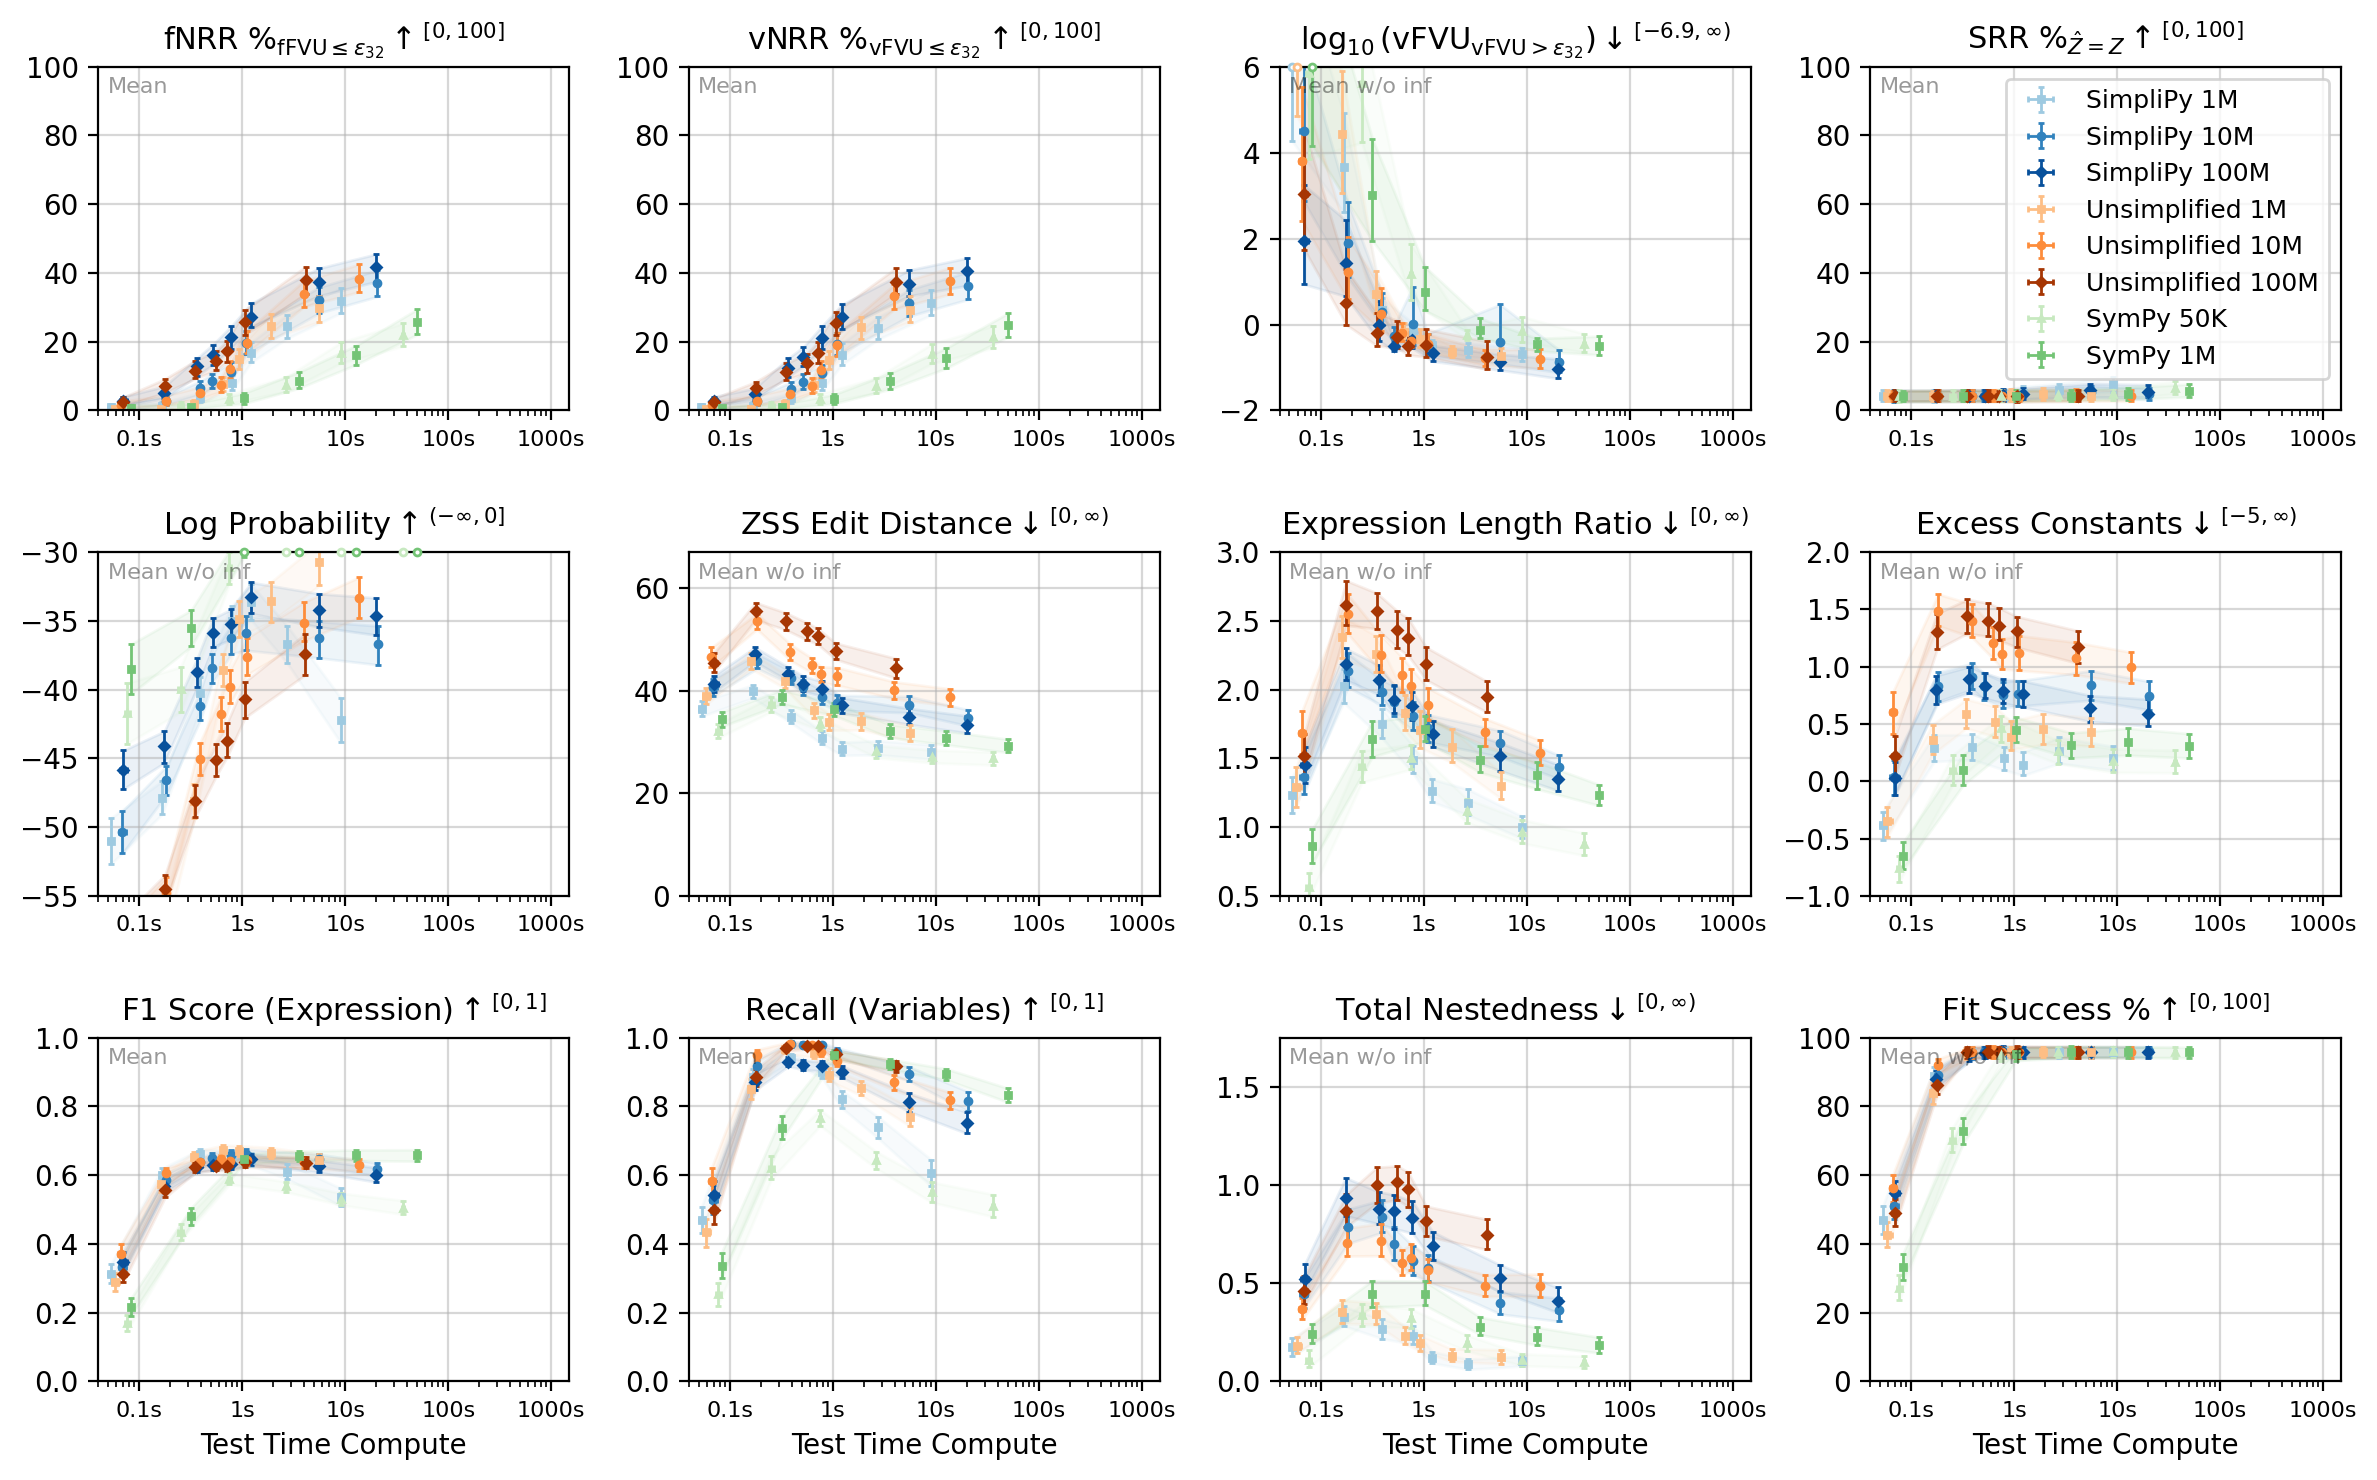

In [70]:
# Determine max_gt_constants from the first available model/scaling level
first_model = list(results.keys())[0]
first_test_set = TEST_SETS[0]
first_scaling_value = sorted(results[first_model]['results'][first_test_set].keys())[0]
gt_constants = results[first_model]['results'][first_test_set][first_scaling_value]['n_constants']
max_gt_constants = max(gt_constants[np.isfinite(gt_constants)])

metric_pairs = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_fit',
        f'fNRR $\\%_{{\\mathrm{{fFVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 100)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'numeric_recovery_val',
        f'vNRR $\\%_{{\\mathrm{{vFVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 100)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'only_approx_log10_fvu_val',
        f'$\\log_{{10}}(\\mathrm{{vFVU}}_{{\\mathrm{{vFVU}} > \\epsilon_{{32}}}}) {arrow_notation(objective=-1, lower=np.log10(np.finfo(np.float32).eps), upper=np.inf)}$',
        naninfmean,
        1,
        (-2, 6)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'symbolic_recovery',
        f'SRR $\\%_{{\\hat{{Z}} = Z}} {arrow_notation(objective=1, lower=0, upper=100)}$',
        np.nanmean,
        100,
        (0, 100)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_log_prob',
        f'$\\mathrm{{Log\\ Probability}} {arrow_notation(objective=1, lower=-np.inf, upper=0)}$',
        naninfmean,
        1,
        (-55, -30)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'zss_edit_distance',
        f'$\\mathrm{{ZSS\\ Edit\\ Distance}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0, 67)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'skeleton_length_ratio',
        f'$\\mathrm{{Expression\\ Length\\ Ratio}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0.5, 3)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'n_constants_delta',
        f'$\\mathrm{{Excess\\ Constants}} {arrow_notation(objective=-1, lower=-max_gt_constants, upper=np.inf)}$',
        naninfmean,
        1,
        (-1, 2)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'f1_score',
        f'$\\mathrm{{F1\\ Score\\ (Expression)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean,
        1,
        (0.0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'recall_unique_variables',
        f'$\\mathrm{{Recall\\ (Variables)}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean,
        1,
        (0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'predicted_total_nestedness',
        f'$\\mathrm{{Total\\ Nestedness}} {arrow_notation(objective=-1, lower=0, upper=np.inf)}$',
        naninfmean,
        1,
        (0, 1.75)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'prediction_success',
        f'$\\mathrm{{Fit\\ Success}}\\ \\% {arrow_notation(objective=1, lower=0, upper=100)}$',
        naninfmean,
        100,
        (0, 100)
    )),
]

# Z-track styling: shared 120M backbone, three inference variants.
# (model_key, scaling_param, color, label, marker)
models = [
    ('v23.0-120M',         'choices',      '#0468BF', '120M softmax + LM (baseline)', 'o'),
    ('v23.0-120M-Z1-bfgs', 'bfgs_choices', '#c53549', '120M softmax + BFGS (Z1)',     's'),
    ('v23.0-120M-Z2-beam', 'beam_search',  '#F28705', '120M beam search (Z2)',        'D'),
]

models = [m for m in models if m[0] in results.keys()]

COLS = min(4, len(metric_pairs))
ROWS = np.ceil(len(metric_pairs) / COLS).astype(int)

if len(TEST_SETS) == 1:
    test_set = TEST_SETS[0]
else:
    test_set = 'fastsrb'

fig, axes = plt.subplots(ROWS, COLS, figsize=(3 * COLS, 2.5 * ROWS), dpi=200)

short_scaling_parameters = {
    1024: '1k',
    2048: '2k',
    4096: '4k',
    8192: '8k',
    16384: '16k',
    32768: '32k',
    65536: '64k',
}

for ax_id, (ax, ((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs)):
    ax: plt.Axes
    for model_name, scaling_param, color, model_label, marker in models:
        x_median, x_lower, x_upper = [], [], []
        y_median, y_lower, y_upper = [], [], []

        if model_name not in results or test_set not in results[model_name]['results']:
            continue

        for n in results[model_name]['results'][test_set].keys():
            x = results[model_name]['results'][test_set][n][x_metric]
            y = results[model_name]['results'][test_set][n][y_metric]

            if y_metric == 'only_approx_log10_fvu_val':
                y = y[y != -np.inf]

            x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95)
            y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95)

            x_median.append(x_ci[0])
            x_lower.append(x_ci[1])
            x_upper.append(x_ci[2])

            y_median.append(y_ci[0])
            y_lower.append(y_ci[1])
            y_upper.append(y_ci[2])

        if ylim[0] is not None and ylim[1] is not None:
            ax.set_ylim(ylim)

        x_median, x_lower, x_upper = np.array(x_median), np.array(x_lower), np.array(x_upper)
        y_median, y_lower, y_upper = np.array(y_median) * y_factor, np.array(y_lower) * y_factor, np.array(y_upper) * y_factor

        ax.errorbar(
            x_median,
            y_median,
            yerr=[y_median - y_lower, y_upper - y_median],
            xerr=[x_median - x_lower, x_upper - x_median],
            fmt=marker,
            linestyle='none',
            label=model_label,
            capsize=1,
            color=color,
            elinewidth=1,
            markersize=2.5,
        )
        ax.fill_between(x_median, y_lower, y_upper, color=color, alpha=0.08)

        # Out-of-bounds indicators
        if ylim[1] is not None:
            oob_mask = y_median > ylim[1]
            if np.any(oob_mask):
                ax.plot(
                    x_median[oob_mask],
                    np.full(oob_mask.sum(), ylim[1]),
                    marker='o', linestyle='None',
                    markerfacecolor='white', markeredgecolor=color,
                    markeredgewidth=1.0, markersize=2.5, clip_on=False, zorder=100
                )

    y_statistic_name = {
        np.nanmean: 'Mean',
        np.nanmedian: 'Median',
        naninfmean: 'Mean w/o inf',
    }
    ax.annotate(y_statistic_name[y_statistic], xy=(0.02, 0.97), xycoords='axes fraction', fontsize=8, color='k', ha='left', va='top', alpha=0.4)

    ax.set_title(y_label, fontsize=11)
    ax.set_xscale('log')
    ax.set_xlim(0.04, 1500)
    ax.set_xticks([0.1, 1, 10, 100, 1000])
    ax.set_xticklabels(['0.1s', '1s', '10s', '100s', '1000s'], fontsize=8)
    ax.grid(alpha=0.5)

    if ax_id // COLS == ROWS - 1:
        ax.set_xlabel(x_label)

axes.flatten()[3].legend(fontsize=9)

for ax_id, ax in enumerate(axes.flatten()[len(metric_pairs):]):
    ax.axis('off')
    if (ax_id + len(metric_pairs)) // COLS == ROWS - 1:
        axes.flatten()[len(metric_pairs) - COLS + (ax_id % COLS)].set_xlabel(x_label)

fig.tight_layout(w_pad=0.5, h_pad=2)
fig.savefig(get_path('results', 'figures', 'z_track_scaling_analysis', create=True, filename=f'z_track_full_metrics_{test_set}.svg'), dpi=200)
plt.show()
